In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn import tree
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, accuracy_score


In [2]:
dataset= pd.read_csv ("card_transdata_son.csv")

In [3]:
print("Size of Dataset:", dataset.shape)
print("-------------------------------------------------------------------------")
dataset.head(10)

Size of Dataset: (1000000, 8)
-------------------------------------------------------------------------


,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0
5,5.586408,13.261073,0.064768,1.0,0.0,0.0,0.0,0.0
6,3.724019,0.956838,0.278465,1.0,0.0,0.0,1.0,0.0
7,4.848247,0.320735,1.273050,1.0,0.0,1.0,0.0,0.0
8,0.876632,2.503609,1.516999,0.0,0.0,0.0,0.0,0.0
9,8.839047,2.970512,2.361683,1.0,0.0,0.0,1.0,0.0


In [4]:
print(dataset.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 8 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   distance_from_home              1000000 non-null  float64
 1   distance_from_last_transaction  1000000 non-null  float64
 2   ratio_to_median_purchase_price  1000000 non-null  float64
 3   repeat_retailer                 1000000 non-null  float64
 4   used_chip                       1000000 non-null  float64
 5   used_pin_number                 1000000 non-null  float64
 6   online_order                    1000000 non-null  float64
 7   fraud                           1000000 non-null  float64
dtypes: float64(8)
memory usage: 61.0 MB
None


In [5]:
print(dataset.isnull().sum())

distance_from_home                0
distance_from_last_transaction    0
ratio_to_median_purchase_price    0
repeat_retailer                   0
used_chip                         0
used_pin_number                   0
online_order                      0
fraud                             0
dtype: int64


In [6]:
print("balance test:\n", dataset['fraud'].value_counts())

balance test:
 fraud
0.0    912597
1.0     87403
Name: count, dtype: int64


In [7]:
data_0 = dataset[dataset.fraud == 0]
data_1 = dataset[dataset.fraud == 1]

data_0_downsampled = resample(data_0, replace=False, n_samples=len(data_1),random_state=42 )

balanced_dataset = pd.concat([data_0_downsampled, data_1])

balanced_dataset = balanced_dataset.sample(frac=1, random_state=42).reset_index(drop=True)

print(balanced_dataset['fraud'].value_counts())

fraud
0.0    87403
1.0    87403
Name: count, dtype: int64


In [8]:
X = balanced_dataset.drop("fraud", axis=1)
Y = balanced_dataset["fraud"]

In [9]:
print(X.shape)

(174806, 7)


In [10]:
column_trans = make_column_transformer(
    (StandardScaler(), ['distance_from_home', 'distance_from_last_transaction', 'ratio_to_median_purchase_price']),
    remainder='passthrough'
)

X = column_trans.fit_transform(X)

print(X.shape)

(174806, 7)


In [11]:
X_train, X_test, Y_train,Y_test = train_test_split( X,Y, test_size= 0.3 , random_state=42)

In [12]:
model_entropy= DecisionTreeClassifier(criterion = 'entropy', random_state=42)

model_gini = DecisionTreeClassifier ( criterion = 'gini', max_depth= 5, random_state=42)

In [13]:
model_gini.fit(X_train, Y_train)
predicts= model_gini.predict(X_test)


print("Accuracy score with test set = ", model_gini.score(X_test, Y_test))
print("Accuracy score with train set = ", model_gini.score(X_train, Y_train))

Accuracy score with test set =  0.9986461233362572
Accuracy score with train set =  0.9983246706547677


In [14]:
model_entropy.fit(X_train, Y_train)

predicts= model_entropy.predict(X_test)



print("Accuracy score with test set = ", model_entropy.score(X_test, Y_test))


Accuracy score with test set =  0.999885587887571


In [15]:
from sklearn.metrics import confusion_matrix, accuracy_score

confusion_matrix(y_true=Y_test, y_pred= predicts)

array([[26244,     4],
       [    2, 26192]])

In [16]:


print("Success : " , accuracy_score ( y_true= Y_test, y_pred= predicts))

Success :  0.999885587887571


In [17]:
feature_names = [
    'distance_from_home',
    'distance_from_last_transaction',
    'ratio_to_median_purchase_price',


    'used_chip',
    'used_pin_number',
    'repeat_retailer',
    'online_order'
]

In [18]:

gini_tree_text = tree.export_text(model_gini, feature_names=feature_names)
print("Gini Kriterli Karar Ağacı Yapısı:")
print(gini_tree_text)

Gini Kriterli Karar Ağacı Yapısı:
|--- ratio_to_median_purchase_price <= 0.06
|   |--- distance_from_home <= 0.53
|   |   |--- distance_from_last_transaction <= 1.08
|   |   |   |--- class: 0.0
|   |   |--- distance_from_last_transaction >  1.08
|   |   |   |--- online_order <= 0.50
|   |   |   |   |--- class: 0.0
|   |   |   |--- online_order >  0.50
|   |   |   |   |--- used_pin_number <= 0.50
|   |   |   |   |   |--- class: 1.0
|   |   |   |   |--- used_pin_number >  0.50
|   |   |   |   |   |--- class: 1.0
|   |--- distance_from_home >  0.53
|   |   |--- used_pin_number <= 0.50
|   |   |   |--- online_order <= 0.50
|   |   |   |   |--- distance_from_last_transaction <= 1.08
|   |   |   |   |   |--- class: 0.0
|   |   |   |   |--- distance_from_last_transaction >  1.08
|   |   |   |   |   |--- class: 1.0
|   |   |   |--- online_order >  0.50
|   |   |   |   |--- repeat_retailer <= 0.50
|   |   |   |   |   |--- class: 1.0
|   |   |   |   |--- repeat_retailer >  0.50
|   |   |   |   |

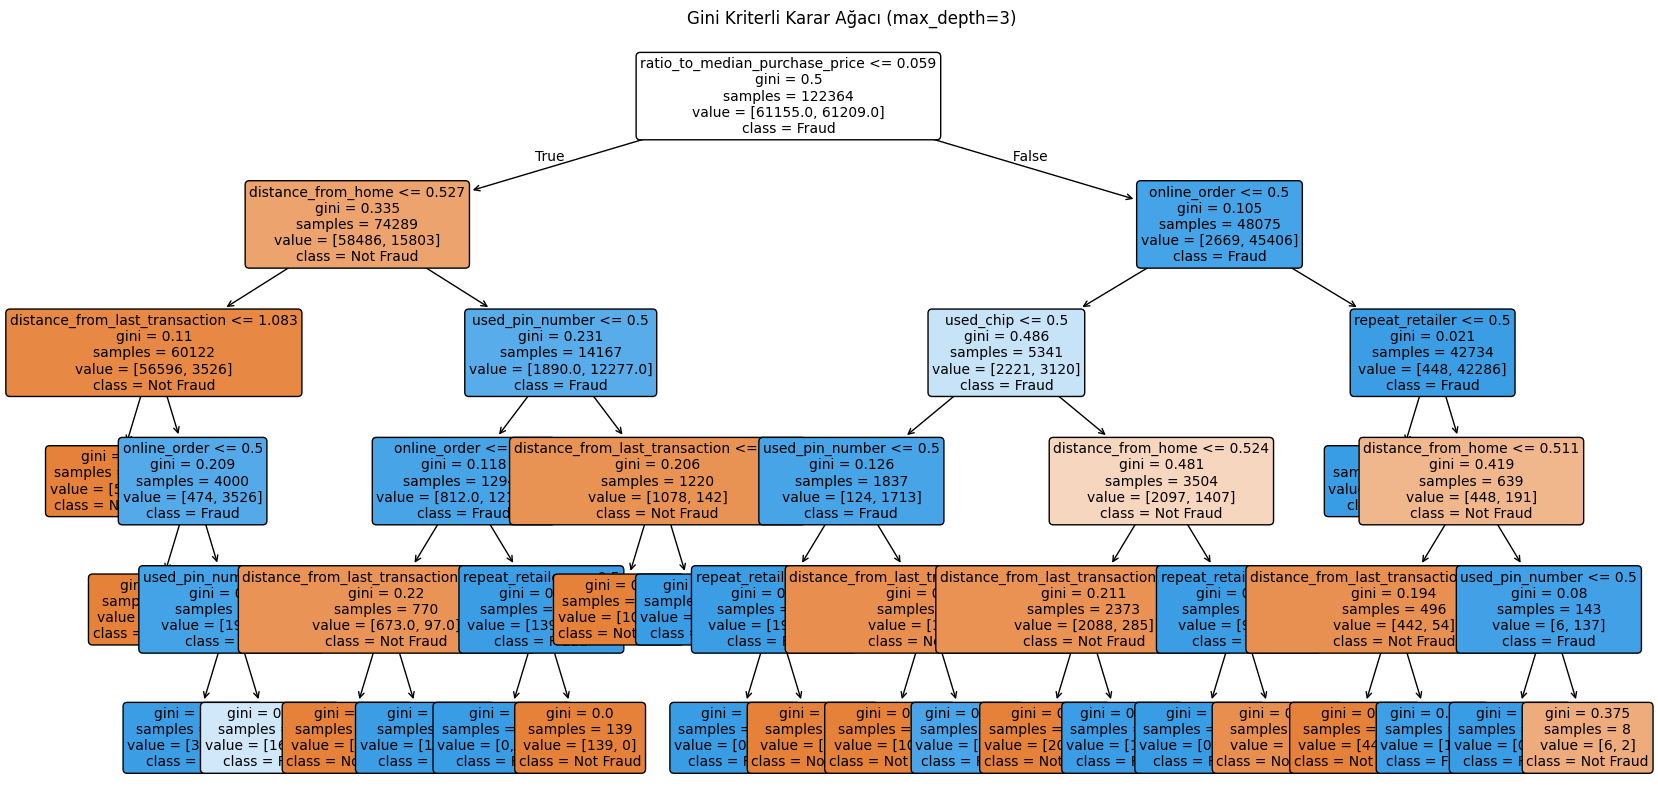

In [19]:

plt.figure(figsize=(20, 10))
plot_tree(model_gini,
          feature_names=feature_names,
          class_names=['Not Fraud', 'Fraud'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Gini Kriterli Karar Ağacı (max_depth=3)")
plt.show()